# OHC Hovmöller and lagged flux–OHC correlation — alternate spin-ups vs Full-CPL

Figures:
* `hov_OHC_Global_0001-0350.pdf`
* `lagcorr_qnet_ohc_0001-0220.pdf`
* `lagcorr_qnet_ohc_0221-0350.pdf`
* `lagcorr_qsource_ohc_0001-0220.pdf`

**Setup** holds everything you normally change: paths, the experiment table, labels, colors and years. Each analysis step then has a **settings** cell (its parameters and plot style) and a **compute & plot** cell that calls the shared classes in `../util/` directly. Figures are saved to `FIG_DIR` (public_html) and cached/derived data to `DATA_DIR` (public_html `data/`, indexed in `data/README.md`).

**Note:** All inputs and outputs of the lag correlation live in `data/ohc_corr/`: the OHC Hovmöller files written by step 1, and annual Q̄net / Q̄source built from the monthly cache of `5_ohu_compare_analysis` (`data/ohu/`) — **run notebook 5 first**. Q̄source is Qsw + Qlw_dn, the definition in the notebook 5 figure. Correlation files carry the flux name.

In [1]:
import os, sys
WF_ROOT = os.path.abspath("..")            # coupled_spinup_eval/
if WF_ROOT not in sys.path:
    sys.path.insert(0, WF_ROOT)
os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")
%matplotlib inline

import os, glob, re
import cftime
import numpy as np
import xarray as xr
from scipy import signal
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FixedLocator, FixedFormatter, MultipleLocator, NullFormatter
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as mticker
from typing import Union, Optional
from datetime import datetime, timezone
from typing import Dict, Sequence, Optional
from datetime import datetime

from util.experiments import build_exp_subdirs_from_run_dict, make_run_dict
from util.figures import publish
from util.regional_timeseries import LaggedOHCCorrelation, OHCHovmollerPlotter, write_annual_flux

## Setup

In [2]:
# ---- paths ----
MODEL_ROOT   = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/E3SMv3_testings"     # case directories
OUTPUT_ROOT  = "/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper"   # published figures/ and data/
OUTPUT_URL   = "https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper"
FIG_DIR      = f"{OUTPUT_ROOT}/figures/ohc_corr"
DATA_DIR     = f"{OUTPUT_ROOT}/data/ohc_corr"              # cached/derived data (index: data/README.md)
OBS_DIR      = f"{OUTPUT_ROOT}/data/obs"                                          # HadSST Nino3.4 reference

# ---- experiments: case directory names (under MODEL_ROOT) and model-year periods ----
EXPERIMENTS = {
    "Full-CPL": {
        "spin-up":   {"name": "20231209.v3.LR.piControl-spinup.chrysalis",      "period": "0001-2000"},
        "piControl": {"name": "v3.LR.piControl",                                "period": "0001-0500"},
    },
    "AltBG1": {
        "spin-up":   {"name": "20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0001-0220"},
        "piControl": {"name": "20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0221-0350"},
    },
    "AltBG2": {
        "spin-up":   {"name": "20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0001-0220"},
        "piControl": {"name": "20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0221-0350"},
    },
    "AltBG3": {
        "spin-up":   {"name": "20241105.v3.LR.piControl.Rerun.BC2GC.anvil",     "period": "0001-2000"},
        "piControl": {"name": "20241105.v3.LR.piControl.Rerun.BC2GC.anvil",     "period": "0001-0500"},
    },
}
LABEL = {"Full-CPL": "FC", "AltBG1": "FC-FOSI-S1", "AltBG2": "FC-FOSI-S2", "AltBG3": "FC-FOSI-S3"}

# ---- analysis settings ----
EXPS        = ["Full-CPL", "AltBG1", "AltBG2"]   # experiments compared (plotting order)
YEARS       = (1, 350)      # simulation years analysed (selects the MPAS-Analysis ts_0001-0350 run)
CLIMO_LEN   = 50            # climatology length of that MPAS-Analysis run (climo_0301-0350)


In [3]:
# Shared inputs/outputs
run_dict = make_run_dict(EXPERIMENTS, MODEL_ROOT)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
publish(OUTPUT_ROOT, FIG_DIR)
print("figures ->", FIG_DIR)
print("data    ->", DATA_DIR)
print("web     ->", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))

figures -> /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/figures/ohc_corr
data    -> /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/data/ohc_corr
web     -> https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/ohc_corr


## 1 OHC depth–time Hovmöller
### Settings

In [4]:
# === Paths ===
data_dir    = MODEL_ROOT
mpas_depth  = f"{OUTPUT_ROOT}/data/grid/depth.nc"
out_dir     = DATA_DIR   # ohc_hov_* inputs of step 2
fig_dir     = FIG_DIR  # or os.path.join(results_dir, "figures")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(fig_dir, exist_ok=True)

# --- Window & labels ---
step_yrs  = 25
climo_len = CLIMO_LEN

time_origin = "0001-01-01 00:00:00"  # origin if time is absent in files
ts_window   = YEARS               # simulation years
year_min, year_max = ts_window
year_token = f"{year_min:04d}-{year_max:04d}"
year_min, year_max = year_min-1, year_max+1

# --- Experiments (in desired plotting order) ---
exp_type = "spin-up"
exp_tags = EXPS   # your chosen order
labels   = [LABEL[t] for t in EXPS]
# One list per experiment (panel). Values are YEARS by default.
vlines_per_exp = [
    [],                 # none for exps[2]
    [11,20,81,90,151,160],          # lines for exps[1]
    [11,60],
]
vline_mode="year"                # or "index" if you pass raw indices
vline_kwargs=dict(color="k", linestyle="--", linewidth=1.2, alpha=0.6)
vline_spin = 221

# Requires your helper + run_dict
exp_subdirs = build_exp_subdirs_from_run_dict(
    run_dict=run_dict,
    exp_tags=exp_tags,
    exp_type=exp_type,
    ts_window=ts_window,
    climo_len=climo_len,
    ts_base="post/analysis/mpas_analysis",
)
# keep experiments in the same order as labels/exp_tags
exps = list(exp_subdirs.keys())
subdirs = [exp_subdirs[e] for e in exps]

# --- Region/index (use the MPAS analysis regional layer-means index) ---
reg_dict = {
    "Arctic"         : {"name": "arctic",     "index": 0},
    "Equator"        : {"name": "equatorial", "index": 1},
    "Southern Ocean" : {"name": "so",         "index": 2},
    "Nino3"          : {"name": "nino3",      "index": 3},
    "Nino4"          : {"name": "nino4",      "index": 4},
    "Nino3.4"        : {"name": "nino3.4",    "index": 5},
    "Global"         : {"name": "global",     "index": 6},  # <- corrected name
}
region   = "Global"
reg_ind  = reg_dict[region]["index"]
reg_dim  = "nOceanRegions"
reg_var  = None
reg_name = None

reg_ind  = reg_dict[region]["index"]
#ylim = (reg_dict[region]["min"],reg_dict[region]["max"])
title = "" #f"Ocean Heat Content Anomaly ($\Delta$OHC)"

# Variable to plot
file_key = "mpasTimeSeriesOcean"
vname   = "OHC"
mpasvar = "OHC"
vunit   = r"$10^{22}$ J"
vfac    = 1.0
y_label = fr"$\Delta${vname} ({vunit})"
x_label = "Model Time (year)"
calendar= "noleap" 
cmap    = "RdBu_r"
basmode = "calendar_year"
to_units= "1e22 J" #"GJ/m^2"; "J"
first_N = 12

# Stats windows (last-N-year)
trend_years = 100
trend_unit  = 'per_decade'
figsize     = (13, 10)
fontsize    = 40
annual_mean = True 
anomaly     = True 
xtick_int   = 50

draw_cumulative  = False
title_top   = "ΔOHC (layer)"
title_bottom= "ΔOHC (Cumulative)"
vmin_row1,vmax_row1=None,None
vmin_row2,vmax_row2=None,None
normalize_by_surface_area = False


### Compute & plot

[diag] Annual mean years subset: 1–350 (requested 1–350)
Wrote: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/data/ohc_corr/ohc_hov_20231209.v3.LR.piControl-spinup.chrysalis_total_annual_0001-0350.nc
[diag] Annual mean years subset: 1–350 (requested 1–350)
Wrote: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/data/ohc_corr/ohc_hov_20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis_total_annual_0001-0350.nc
[diag] Annual mean years subset: 1–350 (requested 1–350)
Wrote: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/data/ohc_corr/ohc_hov_20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis_total_annual_0001-0350.nc
web: https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/ohc_corr


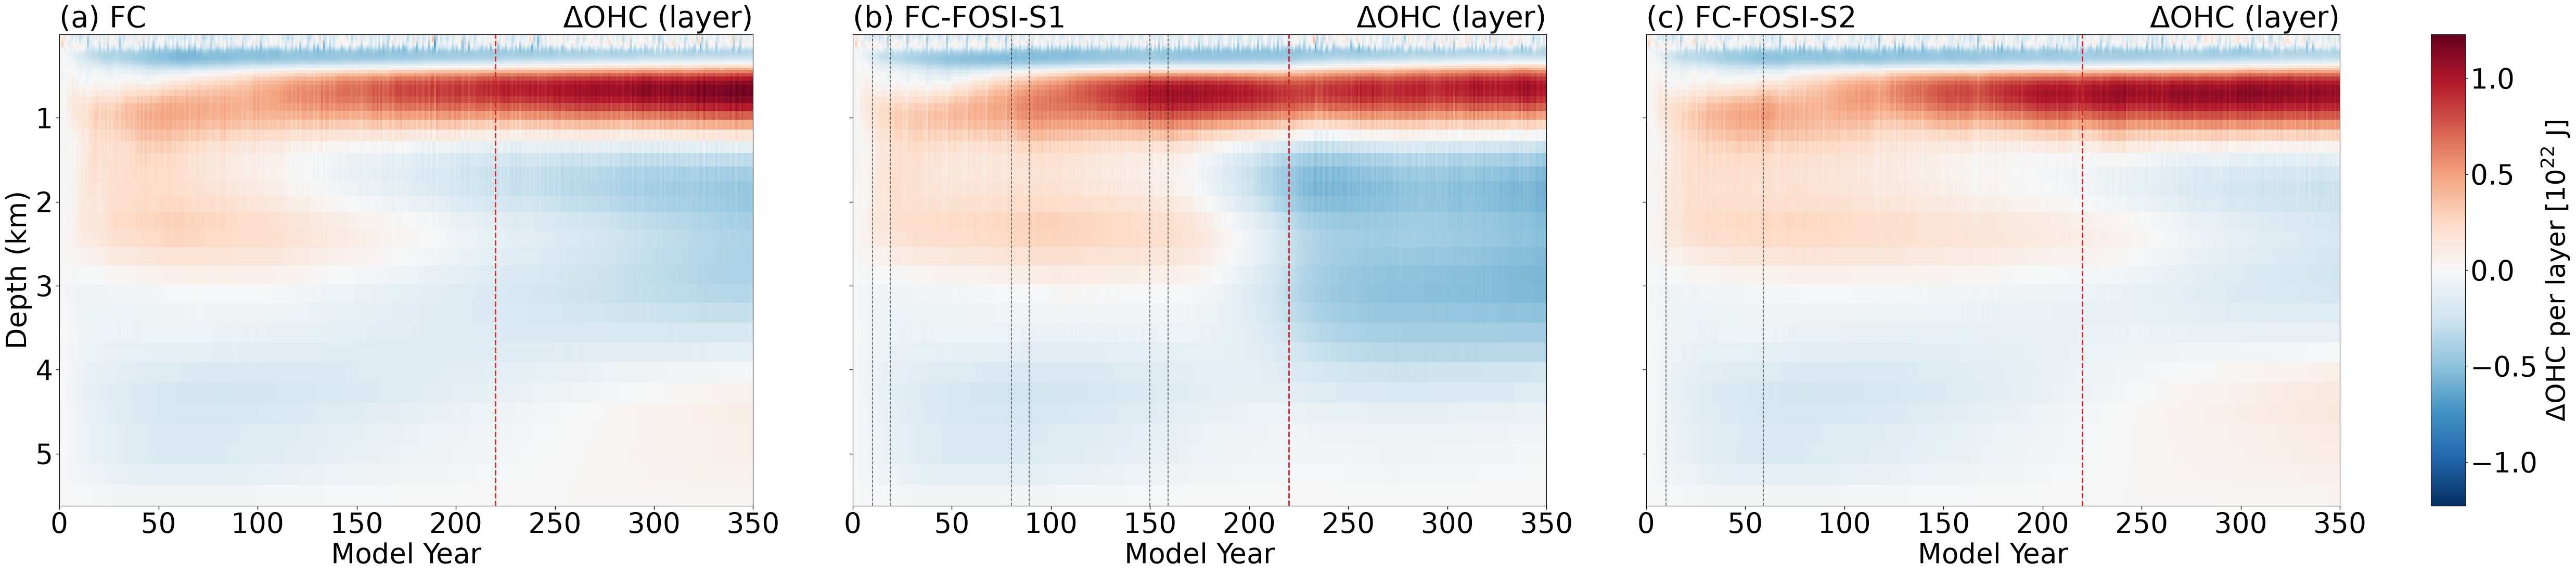

In [5]:
# --- Build plotter (minimal config for Hovmöller row) ---
plotter = OHCHovmollerPlotter(
    mpas_depth=mpas_depth,
    root_dir=data_dir,
    sub_dir=subdirs,                 # overridden per experiment via subdirs
    file_key=file_key,
    var_name=vname,                  # OHC Hovmöller uses layer means T/H internally
    time_origin=time_origin,
    calendar=calendar,
    year_min=year_min, 
    year_max=year_max
)

# --- Hovmöller row (ΔOHC per layer), shared colorbar ---
out_pdf = os.path.join(
    fig_dir, 
    f"hov_OHC_{region}_{year_token}.pdf"
)

plotter.plot_ohc_hovmoller(
    exps=exps,
    labels=labels,
    year_token=year_token,
    subdirs=subdirs,
    outpath=out_dir,
    figsize_per_panel=figsize,
    fontsize=fontsize,
    cmap=cmap,
    # per-layer row scale (auto-symmetric if None)
    vmin_row1=vmin_row1, 
    vmax_row1=vmax_row1,
    # cumulative row scale (auto-symmetric if None)
    vmin_row2=vmin_row2, 
    vmax_row2=vmax_row2,
    to_units=to_units,
    mode="total",                        # or "per_area"
    normalize_by_surface_area=normalize_by_surface_area,     # only applies when mode="total"
    anomaly=anomaly,
    baseline_mode=basmode,
    first_N=first_N,
    draw_cumulative = draw_cumulative, 
    title_top=title_top,
    title_bottom=title_bottom,
    super_title=title,                   # replaces per-panel right titles
    annual_first=annual_mean, 
    xtick_interval=xtick_int,
    vlines_per_exp=vlines_per_exp,    # <-- per-panel lines
    vline_mode=vline_mode,                # or "index" if you pass raw indices
    vline_kwargs=vline_kwargs,
    vline_spin=vline_spin,
    outname=out_pdf,
)

publish(FIG_DIR, DATA_DIR)
print("web:", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))


## 2.0 Annual flux inputs for the lag correlation
Day-weighted annual means of Q̄net and Q̄source from the `5_ohu_compare_analysis` cache.

In [6]:
flux_src_dir = f"{OUTPUT_ROOT}/data/ohu"     # written by 5_ohu_compare_analysis
flux_out_dir = DATA_DIR
for tag in EXPS:
    case = EXPERIMENTS[tag]["spin-up"]["name"]
    src  = os.path.join(flux_src_dir, f"ocean_ohu_diag_Global_ts_yr{YEARS[0]:04d}-{YEARS[1]:04d}_ts_{tag}.nc")
    for var in ("Qnet", "Qsource"):
        print("Wrote:", write_annual_flux(src, var, os.path.join(flux_out_dir, f"FLUX_annual_{case}_{var}_Global_yr1-350.nc"), var.lower()))


Wrote: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/data/ohc_corr/FLUX_annual_20231209.v3.LR.piControl-spinup.chrysalis_Qnet_Global_yr1-350.nc
Wrote: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/data/ohc_corr/FLUX_annual_20231209.v3.LR.piControl-spinup.chrysalis_Qsource_Global_yr1-350.nc
Wrote: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/data/ohc_corr/FLUX_annual_20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis_Qnet_Global_yr1-350.nc
Wrote: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/data/ohc_corr/FLUX_annual_20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis_Qsource_Global_yr1-350.nc
Wrote: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/data/ohc_corr/FLUX_annual_20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis_Qnet_Global_yr1-350.nc
Wrote: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/data/ohc_corr/FLUX_annual_20240818.v3.LR.piControl

## 2.1 Lag correlation, Q̄source, 0001–0220
### Settings

In [7]:
# === Paths ===
data_dir    = DATA_DIR   # ohc_hov_* (step 1), FLUX_annual_* (step 2.0)
mpas_depth  = f"{OUTPUT_ROOT}/data/grid/depth.nc"
ts_base = "post/analysis/mpas_analysis"

fig_dir = FIG_DIR  # or os.path.join(results_dir, "figures")
os.makedirs(fig_dir, exist_ok=True)

# Optional window for pretty axis ticks if you later add custom plotting
ts_window   = (1, 220)
year_min, year_max = ts_window
year_token = f"{year_min:04d}-{year_max:04d}"
year_min, year_max = year_min-1, year_max+1

# === Your files ===
ohc_files = {
    "FC":
        f"{data_dir}/ohc_hov_20231209.v3.LR.piControl-spinup.chrysalis_total_annual_0001-0350.nc",
    "FC-FOSI-S1":
        f"{data_dir}/ohc_hov_20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis_total_annual_0001-0350.nc",
    "FC-FOSI-S2":
        f"{data_dir}/ohc_hov_20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis_total_annual_0001-0350.nc",
}
qnet_files = {
    "FC":
        f"{data_dir}/FLUX_annual_20231209.v3.LR.piControl-spinup.chrysalis_Qsource_Global_yr1-350.nc",
    "FC-FOSI-S1":
        f"{data_dir}/FLUX_annual_20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis_Qsource_Global_yr1-350.nc",
    "FC-FOSI-S2":
        f"{data_dir}/FLUX_annual_20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis_Qsource_Global_yr1-350.nc",
}

# --- Experiments (in desired plotting order) ---
exp_tags = list(ohc_files.keys())
labels   = list(ohc_files.keys())

lags = list(np.linspace(0, 100, 101, dtype=int)) #[0, 2, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
vmax = 0.5
make_plots = True
ylabel = "Depth"
xlabel = "Lag (years)"
row_title = r"$r\left(\bar{Q}_{\mathrm{source}},\ \Delta\mathrm{OHC}\right)$"
figsize = (18, 16)
fontsize = 60 

# If your files use different names, keep these overrides; otherwise set to None to auto-detect
ohc_var    = "ohc"
qnet_var   = "qsource"
time_name  = None
depth_name = "depth"
detrend = False
decode_times = False
fig_idx = 0
xtick_int = 10


### Compute & plot

(101, 64)
(101, 64)
(101, 64)


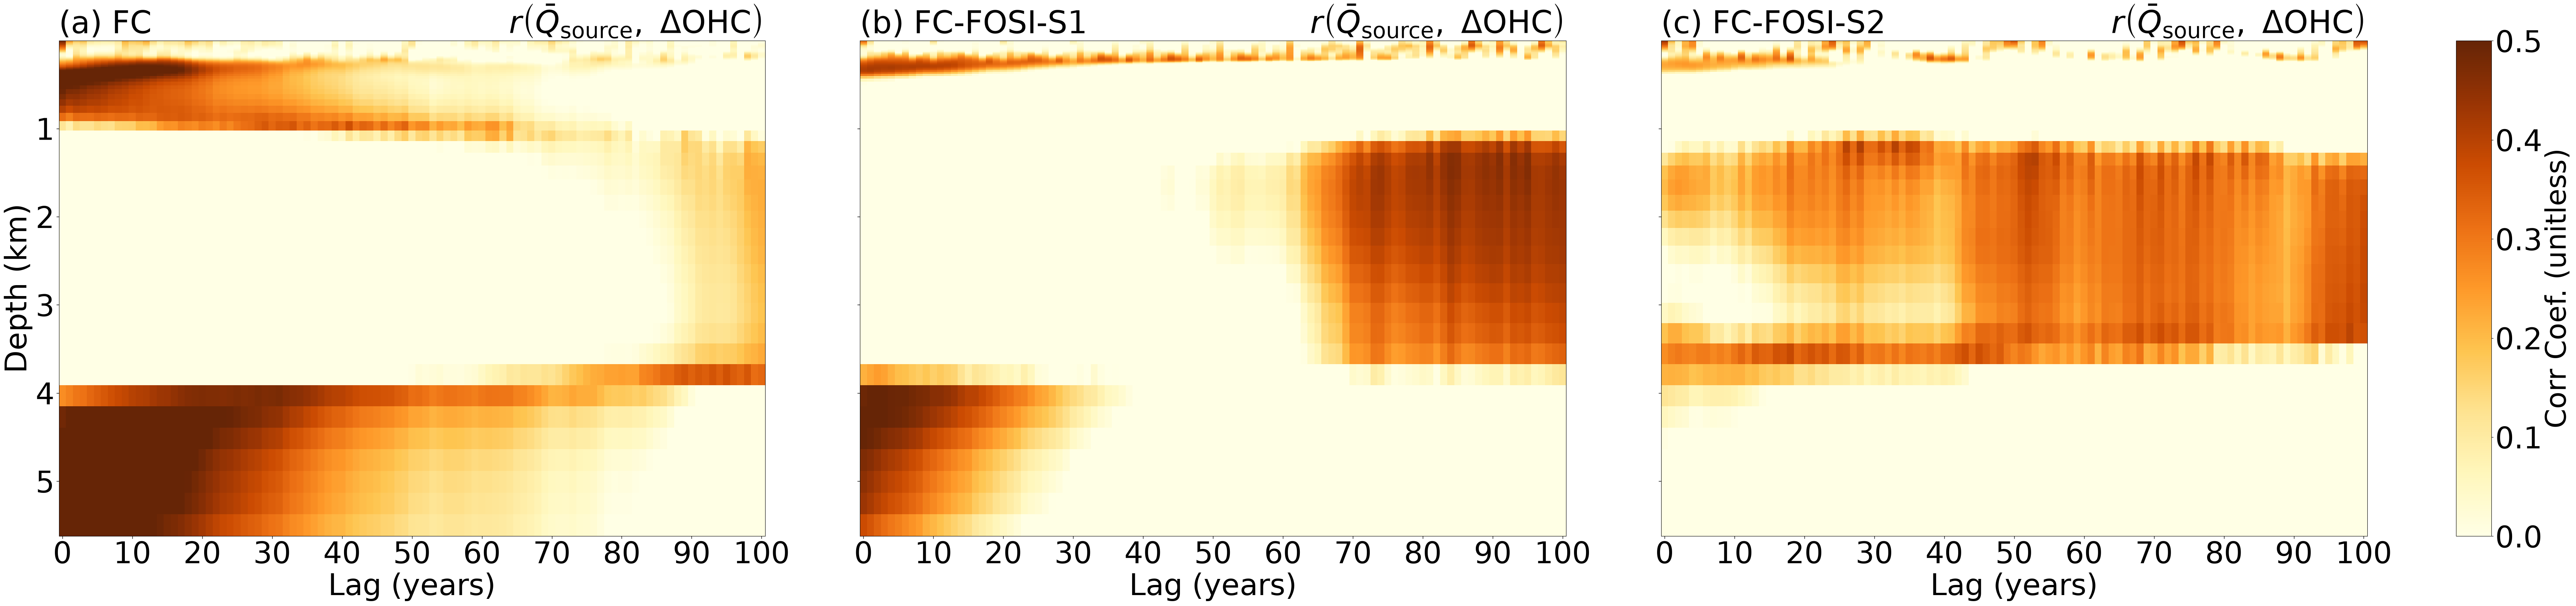

Saved combined plot to /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/figures/ohc_corr/lagcorr_qsource_ohc_0001-0220.pdf
<xarray.Dataset> Size: 311kB
Dimensions:  (lag: 101, exp: 3, z: 64)
Coordinates:
  * lag      (lag) int64 808B 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99 100
  * exp      (exp) <U10 120B 'FC' 'FC-FOSI-S1' 'FC-FOSI-S2'
  * z        (z) float32 256B 0.01 0.02 0.03001 0.04003 ... 5.006 5.253 5.5
Data variables:
    corr     (exp, lag, z) float64 155kB 0.4692 0.4659 ... -0.3713 -0.3706
    beta     (exp, lag, z) float64 155kB 0.03497 0.0349 ... -0.007182 -0.002472
Attributes:
    description:  Lagged correlation between Qnet(t) and OHC(z, t+lag)
    note:         Positive lag means Qnet leads OHC.
web: https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/ohc_corr


In [8]:
corr_engine = LaggedOHCCorrelation(
    ohc_files, qnet_files,
    ohc_var=ohc_var,
    qnet_var=qnet_var,
    time_name=time_name,
    depth_name=depth_name,
    detrend=detrend,
    decode_times=decode_times
)

save_nc = os.path.join(DATA_DIR, f"lagcorr_{qnet_var}_ohc_bydepth_{year_token}.nc")  # <-- removed trailing comma
fig_name = f"lagcorr_qsource_ohc_{year_token}.pdf"
ds_corr = corr_engine.run(
    lags=lags,
    save_nc=save_nc,
    ts_window=ts_window,   # <--- just pass the tuple you already defined
    make_plots=make_plots,
    fig_dir=fig_dir,
    fig_name=fig_name,
    fig_idx=fig_idx,
    vmax=vmax,
    row_title=row_title,
    xtick_interval=xtick_int,  
    ylabel=ylabel,
    xlabel=xlabel,
    fontsize=fontsize,
    figsize=figsize
)

print(ds_corr)

publish(FIG_DIR, DATA_DIR)
print("web:", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))


## 2.2 Lag correlation, Q̄net, 0001–0220
### Settings

In [9]:
# === Paths ===
data_dir    = DATA_DIR   # ohc_hov_* (step 1), FLUX_annual_* (step 2.0)
mpas_depth  = f"{OUTPUT_ROOT}/data/grid/depth.nc"
ts_base = "post/analysis/mpas_analysis"

fig_dir = FIG_DIR  # or os.path.join(results_dir, "figures")
os.makedirs(fig_dir, exist_ok=True)

# Optional window for pretty axis ticks if you later add custom plotting
ts_window   = (1, 220)
year_min, year_max = ts_window
year_token = f"{year_min:04d}-{year_max:04d}"
year_min, year_max = year_min-1, year_max+1

# === Your files ===
ohc_files = {
    "FC":
        f"{data_dir}/ohc_hov_20231209.v3.LR.piControl-spinup.chrysalis_total_annual_0001-0350.nc",
    "FC-FOSI-S1":
        f"{data_dir}/ohc_hov_20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis_total_annual_0001-0350.nc",
    "FC-FOSI-S2":
        f"{data_dir}/ohc_hov_20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis_total_annual_0001-0350.nc",
}
qnet_files = {
    "FC":
        f"{data_dir}/FLUX_annual_20231209.v3.LR.piControl-spinup.chrysalis_Qnet_Global_yr1-350.nc",
    "FC-FOSI-S1":
        f"{data_dir}/FLUX_annual_20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis_Qnet_Global_yr1-350.nc",
    "FC-FOSI-S2":
        f"{data_dir}/FLUX_annual_20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis_Qnet_Global_yr1-350.nc",
}

# --- Experiments (in desired plotting order) ---
exp_tags = list(ohc_files.keys())
labels   = list(ohc_files.keys())

lags = list(np.linspace(0, 100, 101, dtype=int)) #[0, 2, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
vmax = 0.5
make_plots = True
ylabel = "Depth"
xlabel = "Lag (years)"
row_title = r"$r\left(\bar{Q}_{\mathrm{net}},\ \Delta\mathrm{OHC}\right)$"
figsize = (18, 16)
fontsize = 60 

# If your files use different names, keep these overrides; otherwise set to None to auto-detect
ohc_var    = "ohc"
qnet_var   = "qnet"
time_name  = None
depth_name = "depth"
detrend = False
decode_times = False
fig_idx = 0
xtick_int = 10


### Compute & plot

(101, 64)
(101, 64)
(101, 64)


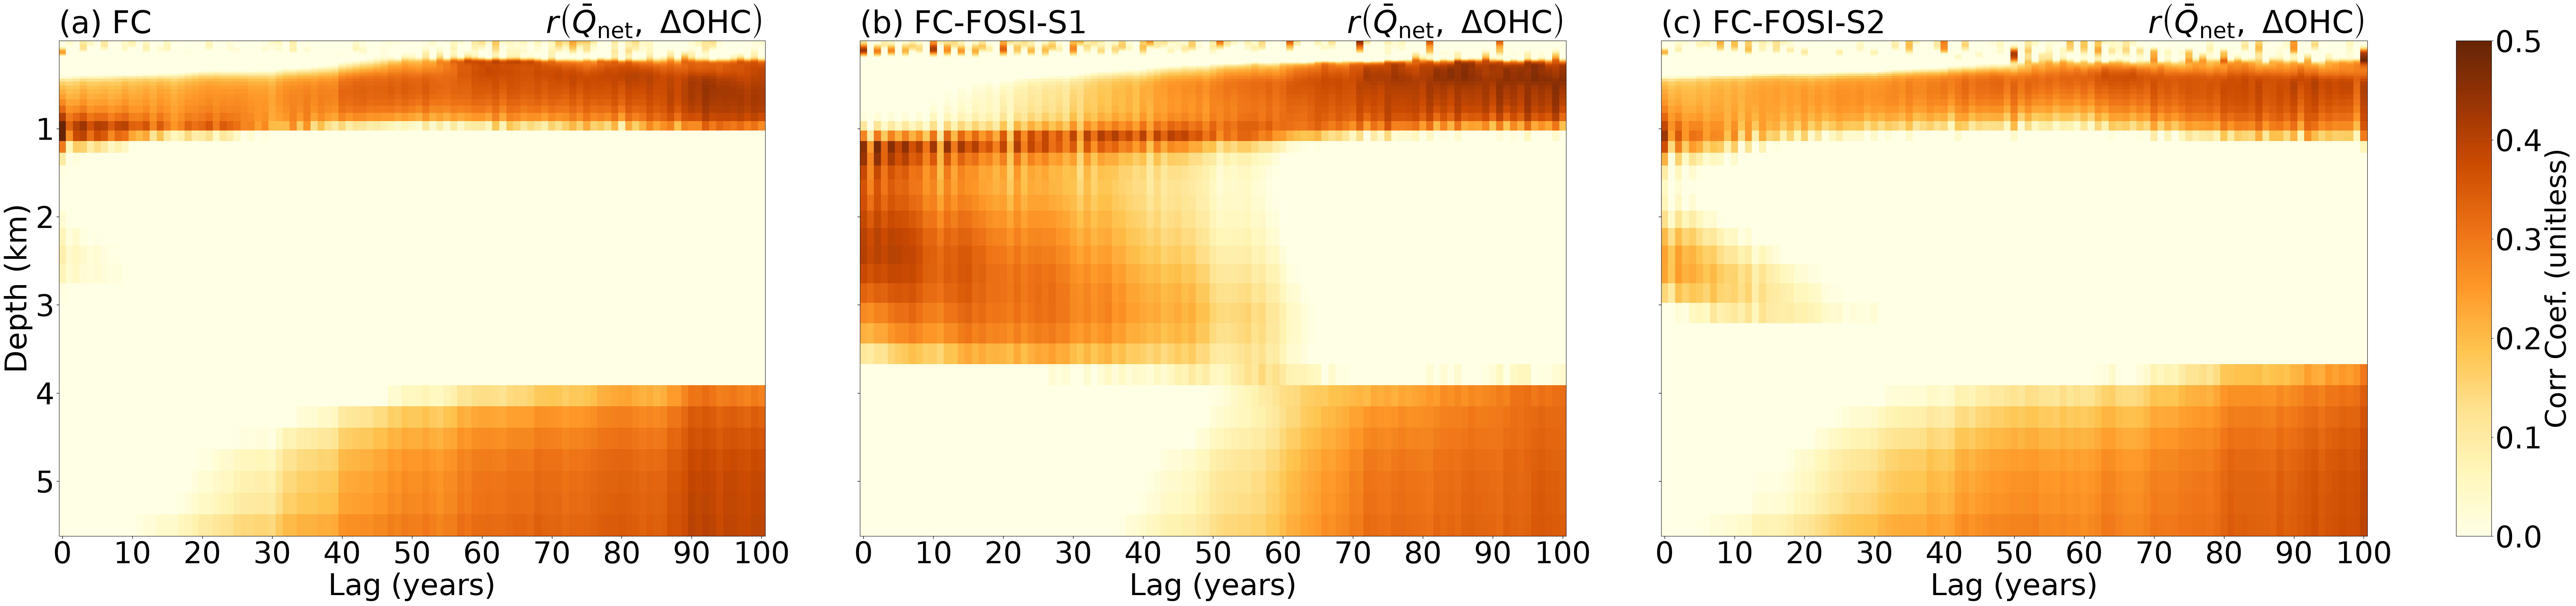

Saved combined plot to /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/figures/ohc_corr/lagcorr_qnet_ohc_0001-0220.pdf
<xarray.Dataset> Size: 311kB
Dimensions:  (lag: 101, exp: 3, z: 64)
Coordinates:
  * lag      (lag) int64 808B 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99 100
  * exp      (exp) <U10 120B 'FC' 'FC-FOSI-S1' 'FC-FOSI-S2'
  * z        (z) float32 256B 0.01 0.02 0.03001 0.04003 ... 5.006 5.253 5.5
Data variables:
    corr     (exp, lag, z) float64 155kB -0.1729 -0.1667 ... 0.3921 0.3933
    beta     (exp, lag, z) float64 155kB -0.02513 -0.02433 ... 0.01235 0.00427
Attributes:
    description:  Lagged correlation between Qnet(t) and OHC(z, t+lag)
    note:         Positive lag means Qnet leads OHC.
web: https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/ohc_corr


In [10]:
corr_engine = LaggedOHCCorrelation(
    ohc_files, qnet_files,
    ohc_var=ohc_var,
    qnet_var=qnet_var,
    time_name=time_name,
    depth_name=depth_name,
    detrend=detrend,
    decode_times=decode_times
)

save_nc = os.path.join(DATA_DIR, f"lagcorr_{qnet_var}_ohc_bydepth_{year_token}.nc")  # <-- removed trailing comma
fig_name = f"lagcorr_qnet_ohc_{year_token}.pdf"
ds_corr = corr_engine.run(
    lags=lags,
    save_nc=save_nc,
    ts_window=ts_window,   # <--- just pass the tuple you already defined
    make_plots=make_plots,
    fig_dir=fig_dir,
    fig_name=fig_name,
    fig_idx=fig_idx,
    vmax=vmax,
    row_title=row_title,
    xtick_interval=xtick_int,  
    ylabel=ylabel,
    xlabel=xlabel,
    fontsize=fontsize,
    figsize=figsize
)

print(ds_corr)

publish(FIG_DIR, DATA_DIR)
print("web:", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))


## 2.3 Lag correlation, Q̄net, 0221–0350
### Settings

In [11]:
# === Paths ===
data_dir    = DATA_DIR   # ohc_hov_* (step 1), FLUX_annual_* (step 2.0)
mpas_depth  = f"{OUTPUT_ROOT}/data/grid/depth.nc"
ts_base = "post/analysis/mpas_analysis"

fig_dir = FIG_DIR  # or os.path.join(results_dir, "figures")
os.makedirs(fig_dir, exist_ok=True)

# Optional window for pretty axis ticks if you later add custom plotting
ts_window   = (221, 350)
year_min, year_max = ts_window
year_token = f"{year_min:04d}-{year_max:04d}"
year_min, year_max = year_min-1, year_max+1

# === Your files ===
ohc_files = {
    "FC":
        f"{data_dir}/ohc_hov_20231209.v3.LR.piControl-spinup.chrysalis_total_annual_0001-0350.nc",
    "FC-FOSI-S1":
        f"{data_dir}/ohc_hov_20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis_total_annual_0001-0350.nc",
    "FC-FOSI-S2":
        f"{data_dir}/ohc_hov_20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis_total_annual_0001-0350.nc",
}
qnet_files = {
    "FC":
        f"{data_dir}/FLUX_annual_20231209.v3.LR.piControl-spinup.chrysalis_Qnet_Global_yr1-350.nc",
    "FC-FOSI-S1":
        f"{data_dir}/FLUX_annual_20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis_Qnet_Global_yr1-350.nc",
    "FC-FOSI-S2":
        f"{data_dir}/FLUX_annual_20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis_Qnet_Global_yr1-350.nc",
}

# --- Experiments (in desired plotting order) ---
exp_tags = list(ohc_files.keys())
labels   = list(ohc_files.keys())

lags = list(np.linspace(0, 50, 51, dtype=int)) #[0, 2, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
vmax = 0.5
make_plots = True
ylabel = "Depth"
xlabel = "Lag (years)"
row_title = r"$r\left(\bar{Q}_{\mathrm{net}},\ \Delta\mathrm{OHC}\right)$"
figsize = (12, 10)
fontsize = 40 

# If your files use different names, keep these overrides; otherwise set to None to auto-detect
ohc_var    = "ohc"
qnet_var   = "qnet"
time_name  = None
depth_name = "depth"
detrend = False
decode_times = False
fig_idx = 6


### Compute & plot

(51, 64)
(51, 64)
(51, 64)


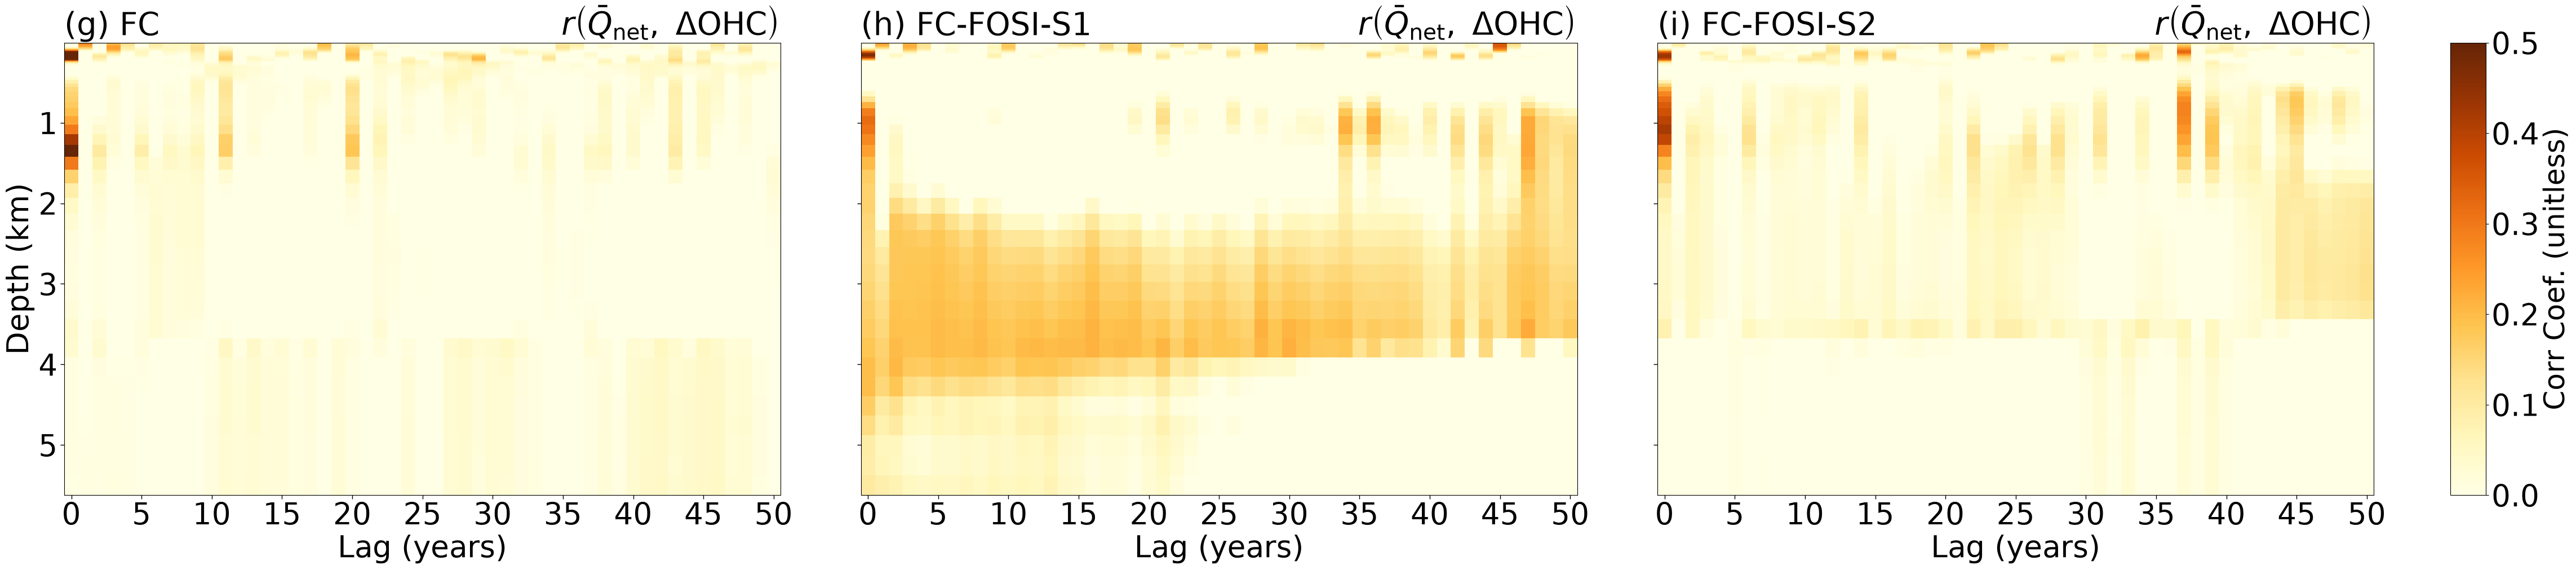

Saved combined plot to /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/figures/ohc_corr/lagcorr_qnet_ohc_0221-0350.pdf
<xarray.Dataset> Size: 157kB
Dimensions:  (lag: 51, exp: 3, z: 64)
Coordinates:
  * lag      (lag) int64 408B 0 1 2 3 4 5 6 7 8 9 ... 42 43 44 45 46 47 48 49 50
  * exp      (exp) <U10 120B 'FC' 'FC-FOSI-S1' 'FC-FOSI-S2'
  * z        (z) float32 256B 0.01 0.02 0.03001 0.04003 ... 5.006 5.253 5.5
Data variables:
    corr     (exp, lag, z) float64 78kB -0.1294 -0.1236 ... -0.1516 -0.1518
    beta     (exp, lag, z) float64 78kB -0.02393 -0.02303 ... -0.001262
Attributes:
    description:  Lagged correlation between Qnet(t) and OHC(z, t+lag)
    note:         Positive lag means Qnet leads OHC.
web: https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/ohc_corr


In [12]:
corr_engine = LaggedOHCCorrelation(
    ohc_files, qnet_files,
    ohc_var=ohc_var,
    qnet_var=qnet_var,
    time_name=time_name,
    depth_name=depth_name,
    detrend=detrend,
    decode_times=decode_times
)

save_nc = os.path.join(DATA_DIR, f"lagcorr_{qnet_var}_ohc_bydepth_{year_token}.nc")  # <-- removed trailing comma
fig_name = f"lagcorr_qnet_ohc_{year_token}.pdf"
ds_corr = corr_engine.run(
    lags=lags,
    save_nc=save_nc,
    ts_window=ts_window,   # <--- just pass the tuple you already defined
    make_plots=make_plots,
    fig_dir=fig_dir,
    fig_name=fig_name,
    fig_idx=fig_idx,
    vmax=vmax,
    row_title=row_title,
    ylabel=ylabel,
    xlabel=xlabel,
    fontsize=fontsize,
    figsize=figsize
)

print(ds_corr)

publish(FIG_DIR, DATA_DIR)
print("web:", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))
